In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import lightgbm as lgb
from statsmodels.tsa.arima.model import ARIMA

In [2]:
df = pd.read_csv('train.csv')
df #date 2013-01-01 to 2017-08-15

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,1,2013-01-01,1,BABY CARE,0.000,0
2,2,2013-01-01,1,BEAUTY,0.000,0
3,3,2013-01-01,1,BEVERAGES,0.000,0
4,4,2013-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [4]:
df['date']= pd.to_datetime(df['date'])

In [5]:
oil = pd.read_csv('oil.csv')
oil #2013-01-01 2017-08-31, full date

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20
...,...,...
1213,2017-08-25,47.65
1214,2017-08-28,46.40
1215,2017-08-29,46.46
1216,2017-08-30,45.96


In [6]:
oil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB


In [7]:
oil['dcoilwtico'].fillna(method='bfill', inplace=True)
oil['date'] = pd.to_datetime(oil['date'])  # Convert 'date' column to datetime 2013-01-01

In [8]:
stores = pd.read_csv('stores.csv')
stores

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4
5,6,Quito,Pichincha,D,13
6,7,Quito,Pichincha,D,8
7,8,Quito,Pichincha,D,8
8,9,Quito,Pichincha,B,6
9,10,Quito,Pichincha,C,15


In [9]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


In [10]:
transactions = pd.read_csv('transactions.csv')
transactions # till 2017-08-15 only

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922
...,...,...,...
83483,2017-08-15,50,2804
83484,2017-08-15,51,1573
83485,2017-08-15,52,2255
83486,2017-08-15,53,932


In [11]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          83488 non-null  object
 1   store_nbr     83488 non-null  int64 
 2   transactions  83488 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.9+ MB


In [12]:
transactions['date'] = pd.to_datetime(transactions['date'])  

In [13]:
df= pd.merge(df, transactions, how='left', on= ['date','store_nbr'])
df

,id,date,store_nbr,family,sales,onpromotion,transactions
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,NaN
1,1,2013-01-01,1,BABY CARE,0.000,0,NaN
2,2,2013-01-01,1,BEAUTY,0.000,0,NaN
3,3,2013-01-01,1,BEVERAGES,0.000,0,NaN
4,4,2013-01-01,1,BOOKS,0.000,0,NaN
...,...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0,2155.0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,2155.0
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148,2155.0
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,2155.0


In [14]:
for date in df['date'].unique():
    daily_sales = df.loc[(df['date'] == date) & (df['sales'] != 0)]
    
    num_families = len(daily_sales['family'].unique())
    
    df.loc[(df['date'] == date) & (df['sales'] != 0), 'ave_transactions'] = daily_sales['transactions'] / num_families

In [15]:
df.ave_transactions= df.ave_transactions.fillna(0)

In [16]:
holidays_events = pd.read_csv('holidays_events.csv')
holidays_events # till 2017-12-22

,date,type,locale,locale_name,description,transferred
0,02-03-12,Holiday,Local,Manta,Fundacion de Manta,False
1,01-04-12,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,12-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,14-04-12,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,21-04-12,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
...,...,...,...,...,...,...
345,22-12-17,Additional,National,Ecuador,Navidad-3,False
346,23-12-17,Additional,National,Ecuador,Navidad-2,False
347,24-12-17,Additional,National,Ecuador,Navidad-1,False
348,25-12-17,Holiday,National,Ecuador,Navidad,False


In [17]:
holidays_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         350 non-null    object
 1   type         350 non-null    object
 2   locale       350 non-null    object
 3   locale_name  350 non-null    object
 4   description  350 non-null    object
 5   transferred  350 non-null    bool  
dtypes: bool(1), object(5)
memory usage: 14.1+ KB


In [18]:
holidays_events['date']= pd.to_datetime(holidays_events['date'])

In [19]:
df= pd.merge(df, stores, how='left', on= 'store_nbr')
df= pd.merge(df, oil, how='left', on= 'date')
df= pd.merge(df, holidays_events, how='left', on= 'date')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3056130 entries, 0 to 3056129
Data columns (total 18 columns):
 #   Column            Dtype         
---  ------            -----         
 0   id                int64         
 1   date              datetime64[ns]
 2   store_nbr         int64         
 3   family            object        
 4   sales             float64       
 5   onpromotion       int64         
 6   transactions      float64       
 7   ave_transactions  float64       
 8   city              object        
 9   state             object        
 10  type_x            object        
 11  cluster           int64         
 12  dcoilwtico        float64       
 13  type_y            object        
 14  locale            object        
 15  locale_name       object        
 16  description       object        
 17  transferred       object        
dtypes: datetime64[ns](1), float64(4), int64(4), object(9)
memory usage: 419.7+ MB


In [21]:
test = pd.read_csv('test.csv')
test #16-08-17, this format need to change else will have issue with other

,id,date,store_nbr,family,onpromotion
0,3000888,16-08-17,1,AUTOMOTIVE,0
1,3000889,16-08-17,1,BABY CARE,0
2,3000890,16-08-17,1,BEAUTY,2
3,3000891,16-08-17,1,BEVERAGES,20
4,3000892,16-08-17,1,BOOKS,0
...,...,...,...,...,...
28507,3029395,31-08-17,9,POULTRY,1
28508,3029396,31-08-17,9,PREPARED FOODS,0
28509,3029397,31-08-17,9,PRODUCE,1
28510,3029398,31-08-17,9,SCHOOL AND OFFICE SUPPLIES,9


In [22]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           28512 non-null  int64 
 1   date         28512 non-null  object
 2   store_nbr    28512 non-null  int64 
 3   family       28512 non-null  object
 4   onpromotion  28512 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.1+ MB


In [23]:
test['date'] = pd.to_datetime(test['date'], dayfirst=True)  # Convert 'date' column to datetime 2013-01-01
passid1= test['id']

In [24]:
test= pd.merge(test, stores, how='left', on= 'store_nbr')
test= pd.merge(test, oil, how='left', on= 'date')
test= pd.merge(test, holidays_events, how='left', on= 'date')

train = pd.concat([df, test], axis=0).reset_index(drop=True)

In [25]:
train.isnull().sum()

id                        0
date                      0
store_nbr                 0
family                    0
sales                 28512
onpromotion               0
transactions         277695
ave_transactions      28512
city                      0
state                     0
type_x                    0
cluster                   0
dcoilwtico           880308
type_y              2571426
locale              2571426
locale_name         2571426
description         2571426
transferred         2571426
dtype: int64

In [26]:
train.type_y.fillna('Work day', inplace=True) # holiday event only record holiday so the rest is Workday
train.transferred.fillna('False', inplace=True) # transferred = true when the day is transferred to another day as holiday
train.transactions.fillna(0, inplace=True)
train.dcoilwtico.fillna(0, inplace=True) 

In [27]:
# reduce memory usage, max value
#Int8	127
#Int16	32,767
#Int32	2,147,483,647
#Int64	2power of 63 - 1

train['store_nbr'] = train.store_nbr.astype("int8") #max 54
train['cluster'] = train.cluster.astype("object") #max 17
train['sales'] = train.sales.astype('float32') #about 20000
train['onpromotion'] = train.onpromotion.astype('int16') # 196
train['dcoilwtico'] = train.dcoilwtico.astype('float32') # 110
train['transactions'] = train.transactions.astype('float32') # about 8400
train['date'] = pd.to_datetime(train['date'], format='mixed', dayfirst=True)  # Convert 'date' column to datetime 2013-01-01

object_cols = train.select_dtypes(include='object').columns
train[object_cols] = train[object_cols].astype('category') #Memory usage is significantly lower, if there are many repeated values

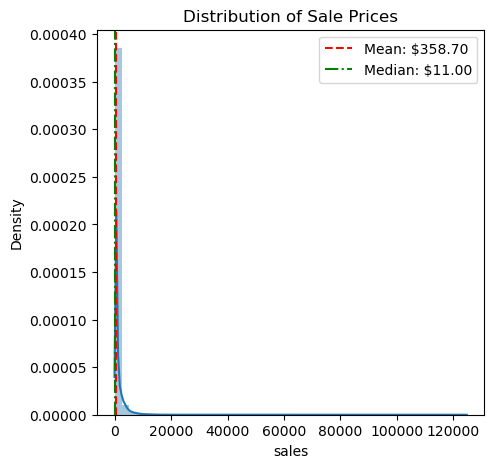

In [28]:
plt.figure(figsize=(5,5))
plt.title("Distribution of Sale Prices")
dist = sns.distplot(train['sales'], norm_hist=False)

mean_price = train['sales'].mean()
median_price = train['sales'].median()
plt.axvline(mean_price, color='r', linestyle='--', label=f'Mean: ${mean_price:,.2f}')
plt.axvline(median_price, color='g', linestyle='-.', label=f'Median: ${median_price:,.2f}')
plt.legend()
plt.show()

In [29]:
print("Skewness: %f" % train['sales'].skew())
print("Kurtosis: %f" % train['sales'].kurt())

Skewness: 7.502282
Kurtosis: 165.597336


array([[<Axes: title={'center': 'id'}>, <Axes: title={'center': 'date'}>,
        <Axes: title={'center': 'store_nbr'}>],
       [<Axes: title={'center': 'sales'}>,
        <Axes: title={'center': 'onpromotion'}>,
        <Axes: title={'center': 'transactions'}>],
       [<Axes: title={'center': 'ave_transactions'}>,
        <Axes: title={'center': 'dcoilwtico'}>, <Axes: >]], dtype=object)

<Figure size 1000x1300 with 0 Axes>

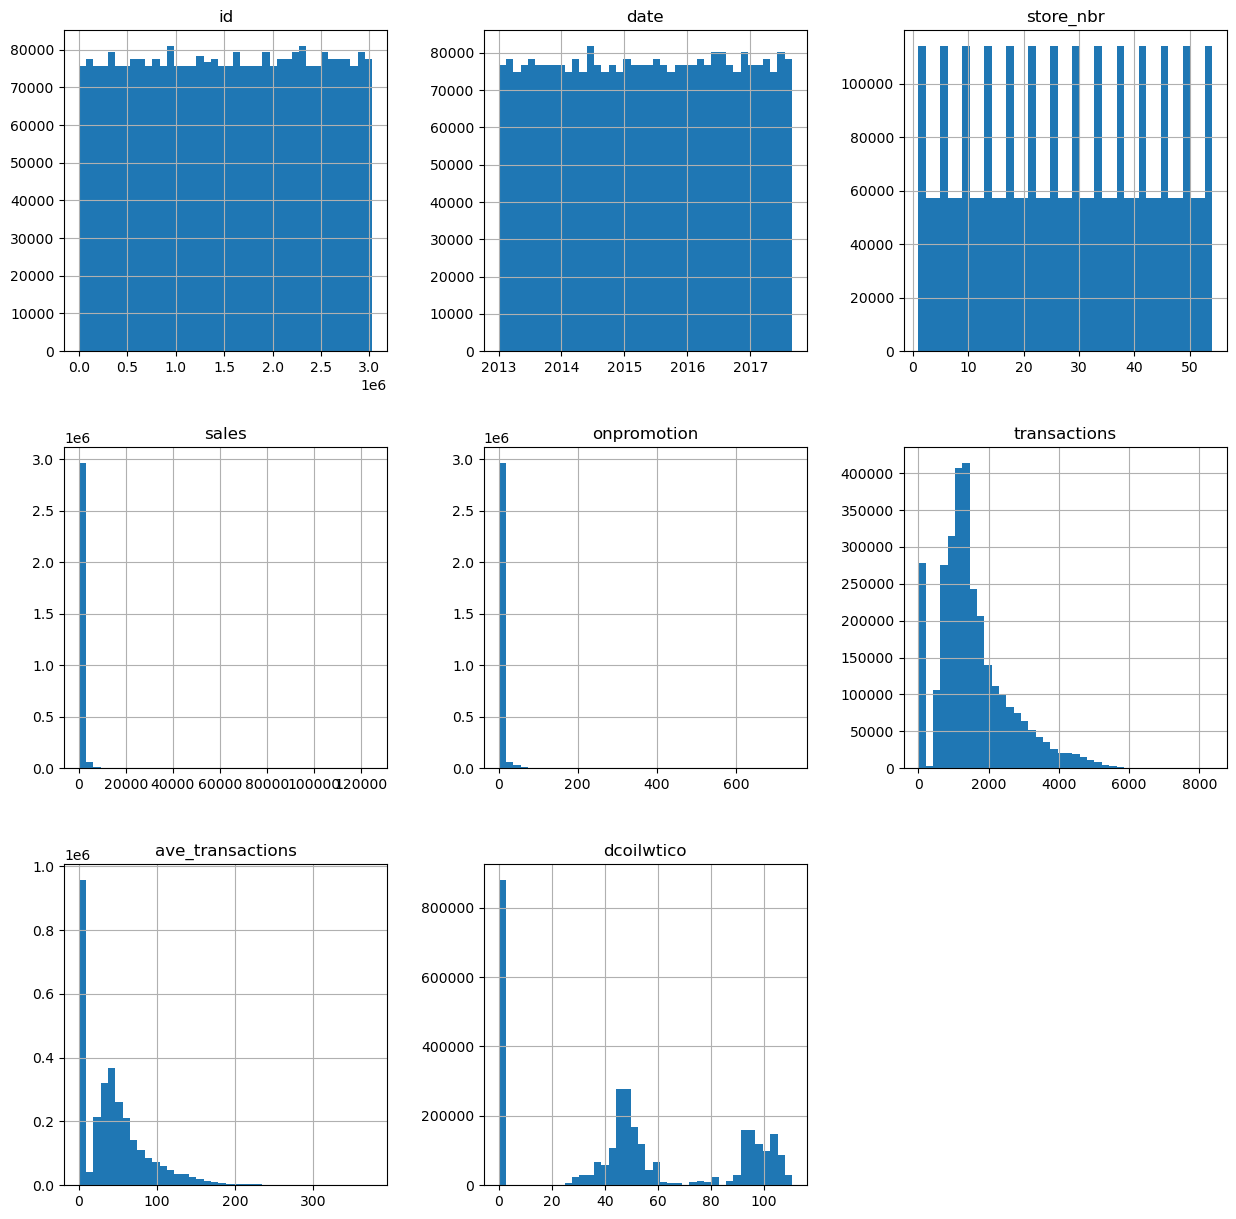

In [30]:
plt.figure(figsize=(10, 13))
train.hist(bins=40, figsize=(15,15))

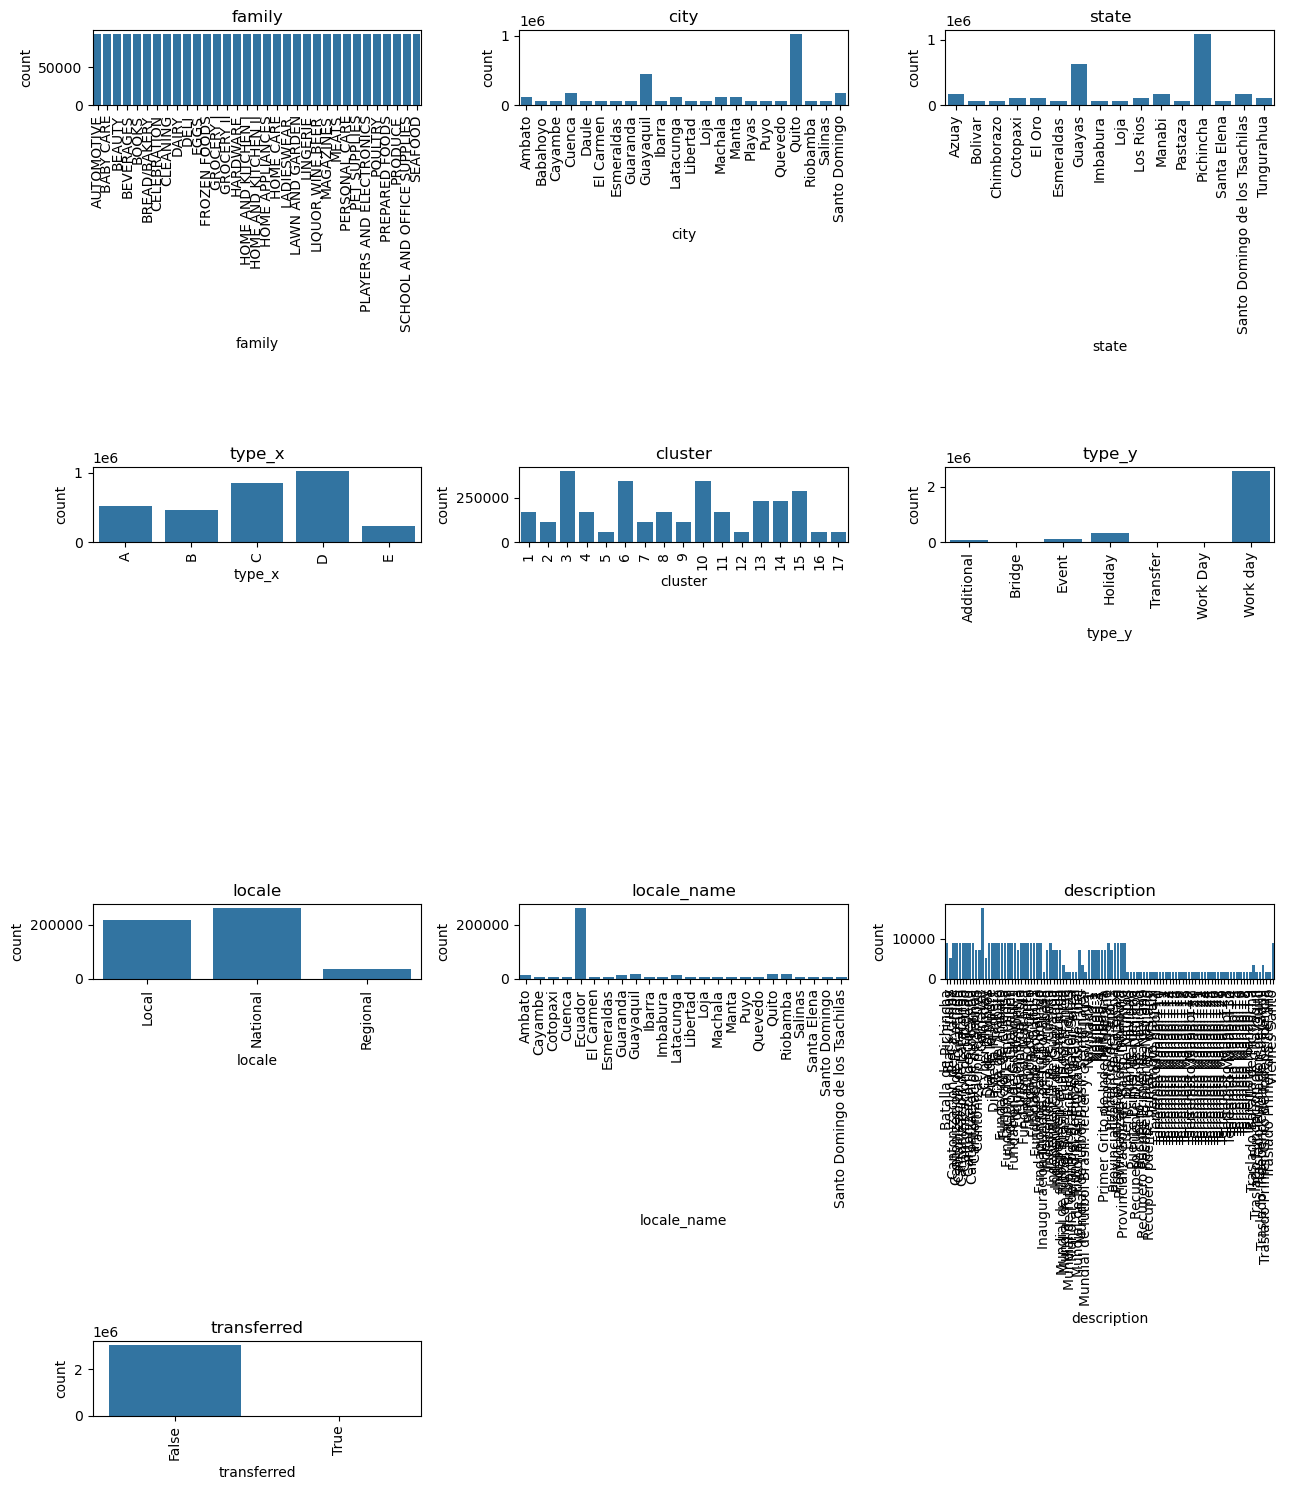

In [31]:
cat_cols = train.select_dtypes(include=['category']).columns.tolist()

plt.figure(figsize=(13, 15))

for index, col in enumerate(cat_cols):
    plt.subplot(4, 3, index + 1)
    sns.countplot(data=train, x=col)
    plt.title(col)
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

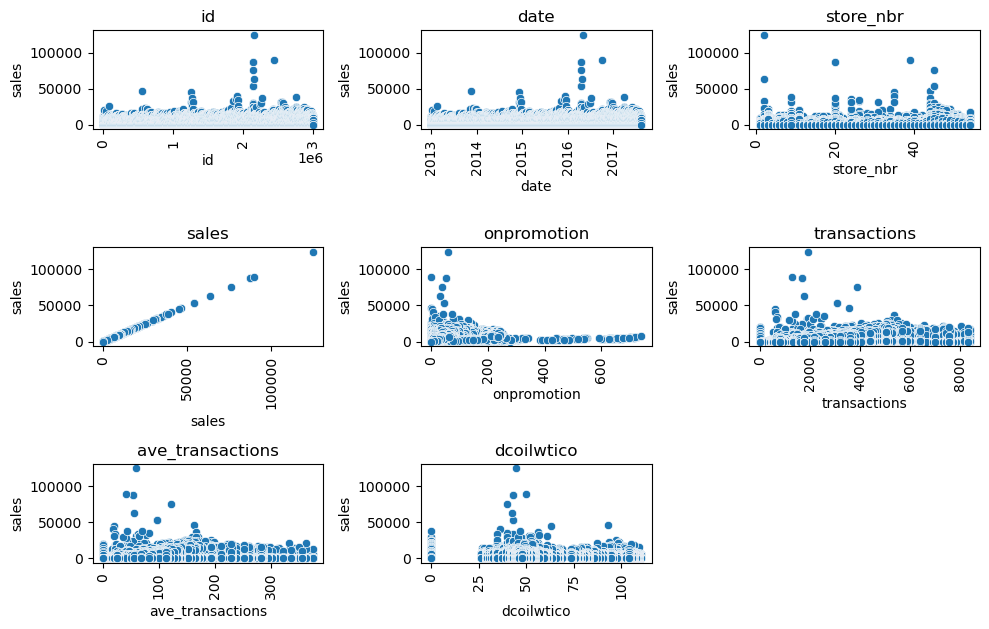

In [32]:
num_cols = train.select_dtypes(exclude=['category']).columns.tolist()

plt.figure(figsize=(10, 8))

for index, col in enumerate(num_cols):
    plt.subplot(4, 3, index + 1)
    sns.scatterplot(data=train, x=col, y= train.sales)
    plt.title(col)
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [33]:
num_cols = train.select_dtypes(exclude=['category'])
numcorr = num_cols.corr()
numcorr[['sales']].sort_values(['sales'], ascending=False).head(15)

,sales
sales,1.000000
onpromotion,0.429418
ave_transactions,0.290690
transactions,0.232843
id,0.085971
date,0.085915
store_nbr,0.041209
dcoilwtico,-0.076417


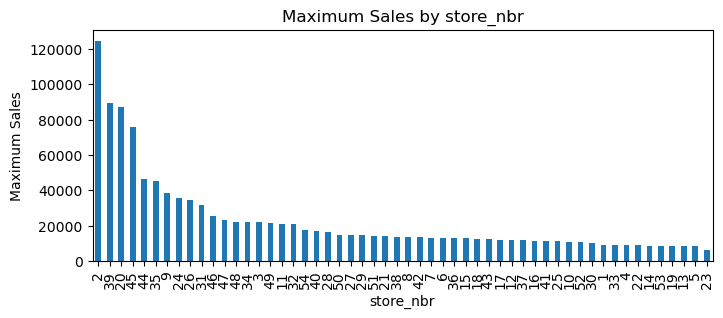

In [34]:
neighborhood_max_sale_price = train.groupby('store_nbr')['sales'].max().sort_values(ascending=False)

neighborhood_max_sale_price.plot(kind='bar', figsize=(8, 3))
plt.title("Maximum Sales by store_nbr")
plt.xlabel("store_nbr")
plt.ylabel("Maximum Sales")
plt.xticks(rotation=90)
plt.show() # 2 have the highest Sales

In [35]:
group2 = train.groupby('store_nbr').get_group(2)
largest_group2 = group2['sales'].nlargest(6)
group2.loc[largest_group2.index, ['family', 'onpromotion', 'sales', 'city','cluster','dcoilwtico', 'transactions']]

,family,onpromotion,sales,city,cluster,dcoilwtico,transactions
2195799,GROCERY I,59,124717.0,Quito,13,44.75000,1905.0
2185107,GROCERY I,30,63434.0,Quito,13,42.53125,1778.0
1882167,GROCERY I,23,33274.0,Quito,13,42.93750,1928.0
2174790,GROCERY I,46,23687.0,Quito,13,43.18750,2019.0
2174791,GROCERY I,46,23687.0,Quito,13,43.18750,2019.0
1933845,GROCERY I,10,15090.0,Quito,13,36.75000,1954.0


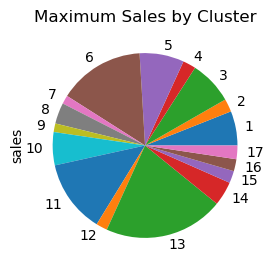

In [36]:
cluster_max_sales = train.groupby('cluster')['sales'].max()

cluster_max_sales.plot(kind='pie', figsize=(8, 3))
plt.title("Maximum Sales by Cluster")
plt.xticks(rotation=90)
plt.show() # 13 have the highest Sales

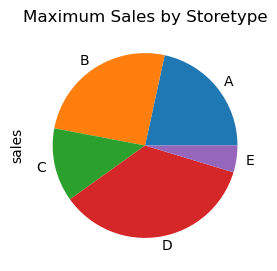

In [37]:
storetype_max_sales = train.groupby('type_x')['sales'].max()

storetype_max_sales.plot(kind='pie', figsize=(8, 3))
plt.title("Maximum Sales by Storetype")
plt.xticks(rotation=90)
plt.show() # D have the highest Sales

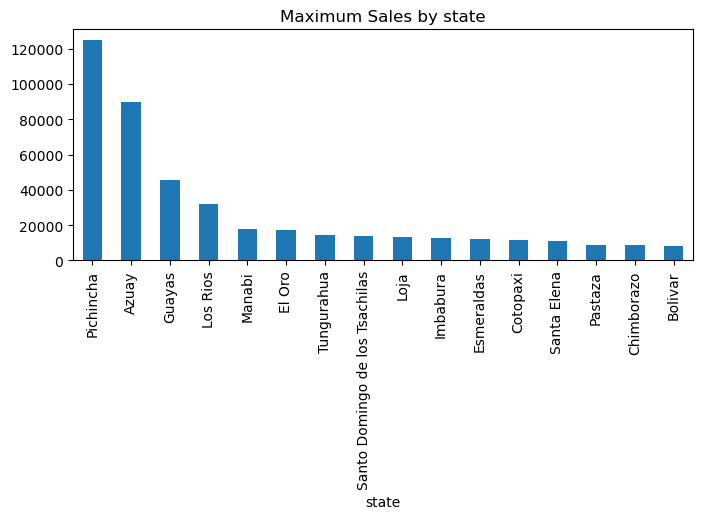

In [38]:
state_max_sales = train.groupby('state')['sales'].max().sort_values(ascending=False)

state_max_sales.plot(kind='bar', figsize=(8, 3))
plt.title("Maximum Sales by state")
plt.xticks(rotation=90)
plt.show() # Pichincha have the highest Sales

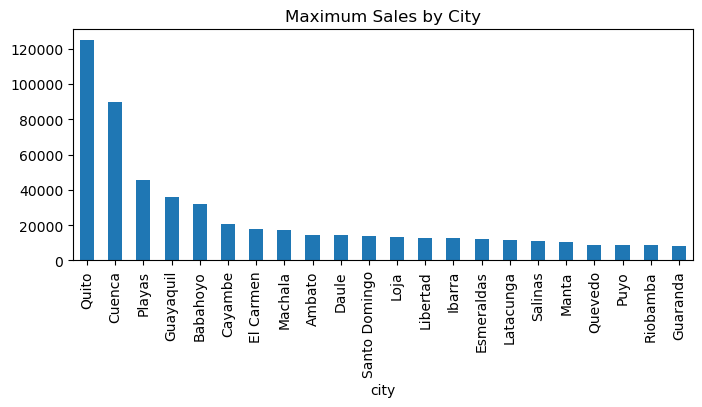

In [39]:
city_max_sales = train.groupby('city')['sales'].max().sort_values(ascending=False)

city_max_sales.plot(kind='bar', figsize=(8, 3))
plt.title("Maximum Sales by City")
plt.xticks(rotation=90)
plt.show() # Quito have the highest Sales

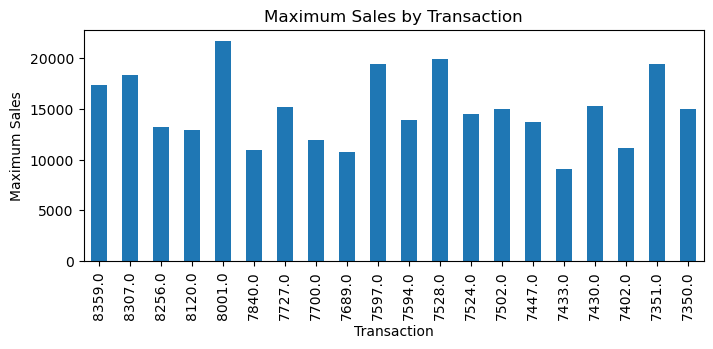

In [40]:
transaction_max_sales = train.groupby('transactions')['sales'].max().sort_index(ascending=False).head(20)

transaction_max_sales.plot(kind='bar', figsize=(8, 3))
plt.title("Maximum Sales by Transaction")
plt.xlabel("Transaction")
plt.ylabel("Maximum Sales")
plt.xticks(rotation=90)
plt.show() # max transaction do not mean highest Sales

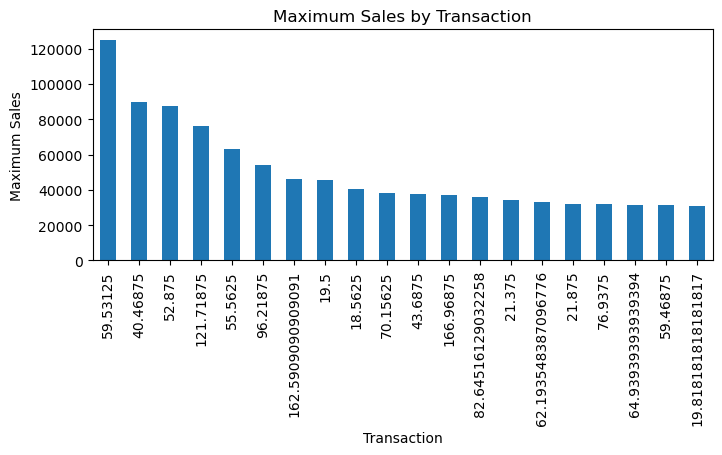

In [41]:
ave_transaction_max_sales = train.groupby('ave_transactions')['sales'].max().sort_values(ascending=False).head(20)

ave_transaction_max_sales.plot(kind='bar', figsize=(8, 3))
plt.title("Maximum Sales by Transaction")
plt.xlabel("Transaction")
plt.ylabel("Maximum Sales")
plt.xticks(rotation=90)
plt.show() # 59 have the highest Sales

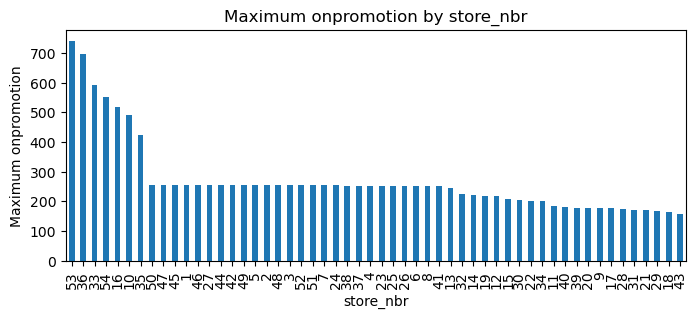

In [42]:
store_nbr_max_onpromotion = train.groupby('store_nbr')['onpromotion'].max().sort_values(ascending=False)

store_nbr_max_onpromotion.plot(kind='bar', figsize=(8, 3))
plt.title("Maximum onpromotion by store_nbr")
plt.xlabel("store_nbr")
plt.ylabel("Maximum onpromotion")
plt.xticks(rotation=90)
plt.show() # 53 have the highest onpromotion items

### Data Cleaning

In [44]:
train.drop(['locale_name', 'locale', 'transactions'], axis=1, inplace=True)

In [46]:
from pandas.tseries.offsets import MonthEnd

train['day'] = train['date'].dt.day  # Extract the day of the month, 1
train['month_end'] = train['date'] + MonthEnd(0)  # Calculate the month end date of the month
train['last_day_of_month'] = train['month_end'].dt.day  # Extract the last day of the month

In [47]:
train_date = train.set_index('date')
daily_sales = train_date.resample('D').sales.mean().to_frame()
weekly_sales = train_date.resample('W').sales.mean().to_frame()
monthly_sales = train_date.resample('M').sales.mean().to_frame()

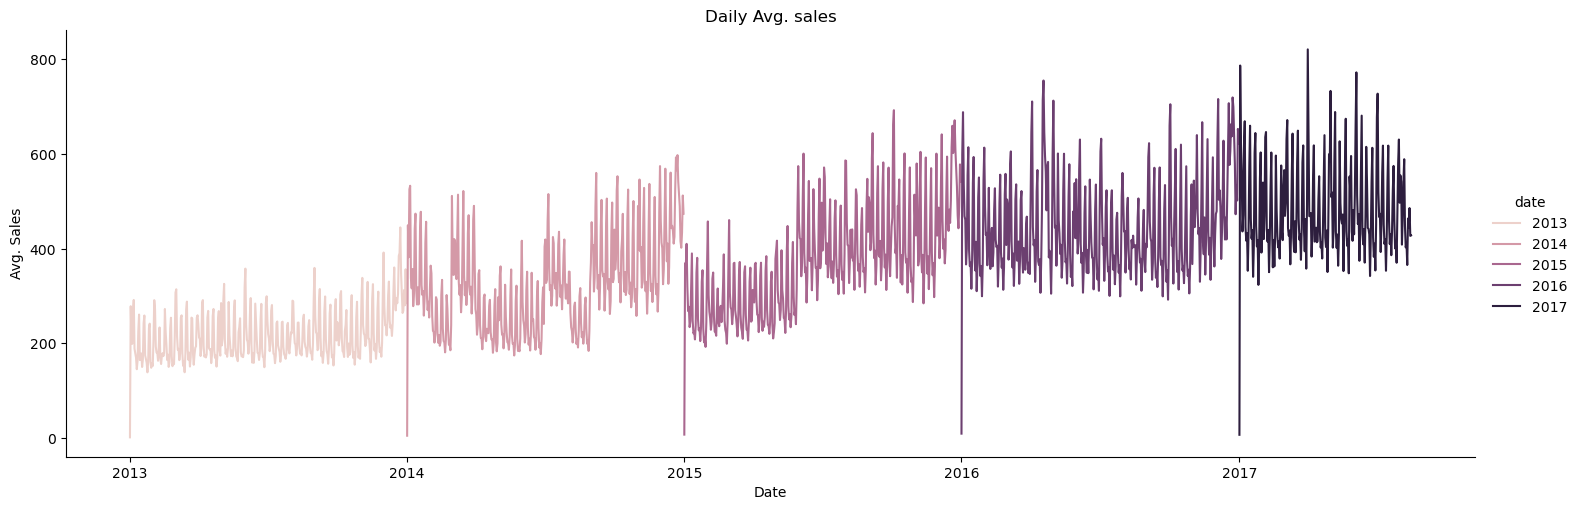

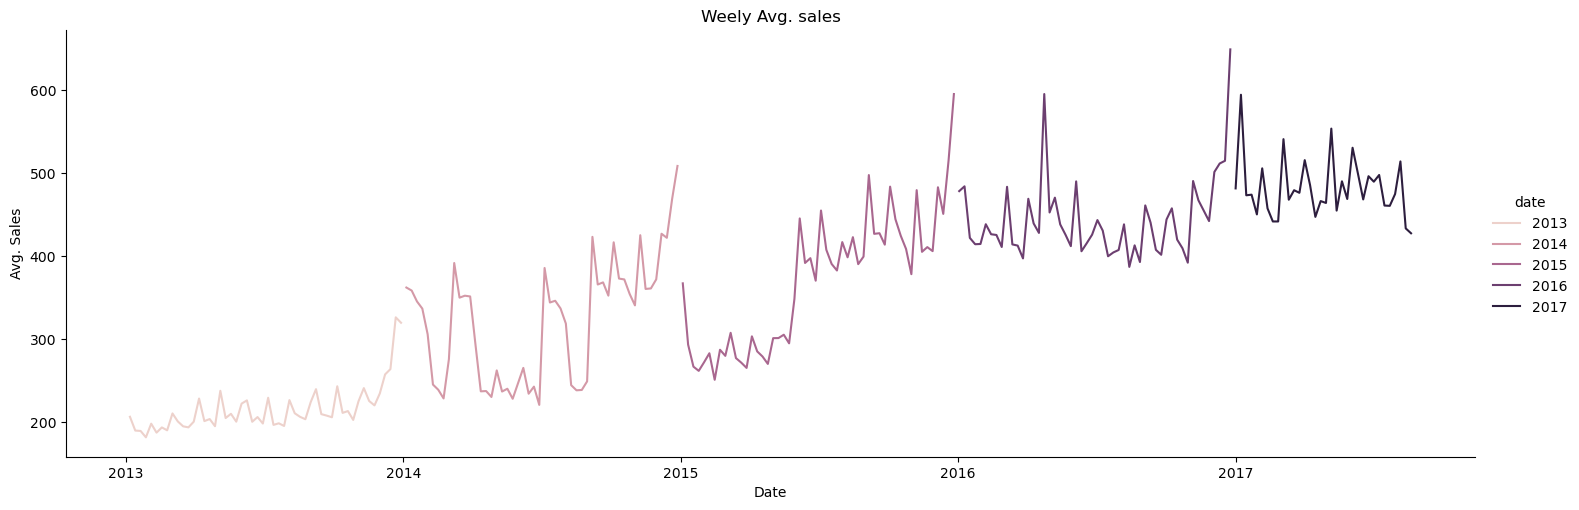

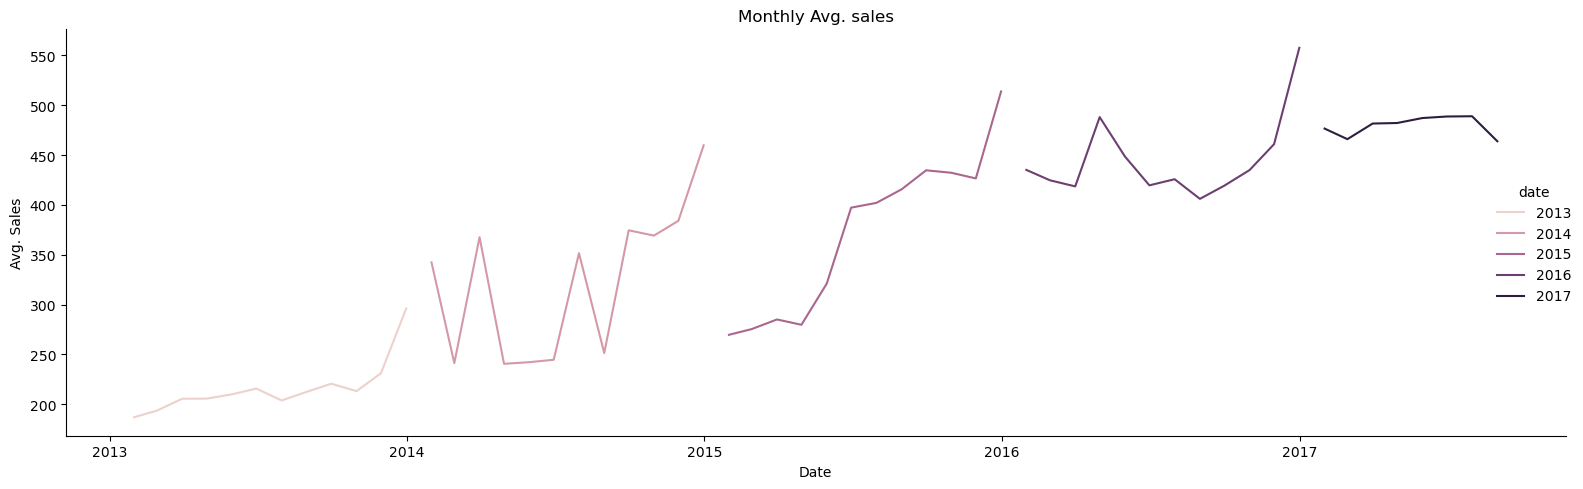

In [48]:
timechart = [daily_sales, weekly_sales, monthly_sales]
title_timechart = ['Daily Avg. sales', 'Weely Avg. sales', 'Monthly Avg. sales']

for i,j in zip(timechart, title_timechart):
    sns.relplot(x=i.index , y=i.sales, kind='line', aspect=3, hue=i.index.year)
    plt.xlabel('Date')
    plt.ylabel('Avg. Sales')
    plt.title(j)
plt.tight_layout()    
plt.show()

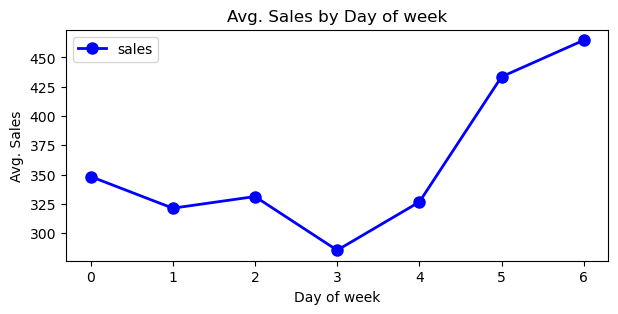

In [49]:
# Calculate the mean sales by day of the week
meansales = train_date.groupby(train_date.index.day_of_week)['sales'].mean().to_frame()

plot_params = {
    'figsize': (7, 3),
    'style': 'o-',      
    'color': 'b',      
    'linewidth': 2,     
    'marker': 'o',     
    'markersize': 8,   
    'legend': True    
}

meansales.plot(**plot_params)
plt.xlabel('Day of week')
plt.ylabel('Avg. Sales')
plt.title('Avg. Sales by Day of week')
plt.show()

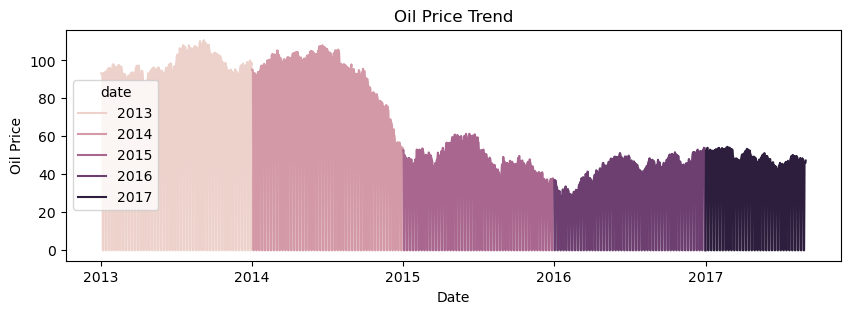

In [50]:
plt.figure(figsize=(10,3))
sns.lineplot(x=train_date.index , y=train['dcoilwtico'], hue=train_date.index.year)
plt.xlabel('Date')
plt.ylabel('Oil Price')
plt.title('Oil Price Trend')
plt.show()

In [51]:
#Wages in the public sector are paid every two weeks on the 15th and on the last day of the month.
#Supermarket sales could be affected by this.
def day_wages(row):
    day = row['day']
    month_end = row['last_day_of_month']
    return 1 if day == 15 or day == month_end else 0

train['wages'] = train.apply(day_wages,axis=1)

In [53]:
train['transferred'] = train['transferred'].astype(str)

def is_holiday(row):
    if row['type_y'] in ['Additional', 'Bridge', 'Event', 'Transfer']:
        return 1
    if row['type_y'] == 'Holiday' and row['transferred'] == 'False':
        return 1
    if row['type_y'] == 'Holiday' and row['transferred'] == 'True':
        return 0
    if row['type_y'] == 'Work Day':
        return 0
    return 0
train['holiday'] = train.apply(is_holiday, axis=1)
train.head()

,id,date,store_nbr,family,sales,onpromotion,ave_transactions,city,state,type_x,cluster,dcoilwtico,type_y,description,transferred,day,month_end,last_day_of_month,wages,holiday
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,0.0,Quito,Pichincha,D,13,93.125,Holiday,Primer dia del ano,False,1,2013-01-31,31,0,1
1,1,2013-01-01,1,BABY CARE,0.0,0,0.0,Quito,Pichincha,D,13,93.125,Holiday,Primer dia del ano,False,1,2013-01-31,31,0,1
2,2,2013-01-01,1,BEAUTY,0.0,0,0.0,Quito,Pichincha,D,13,93.125,Holiday,Primer dia del ano,False,1,2013-01-31,31,0,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,0.0,Quito,Pichincha,D,13,93.125,Holiday,Primer dia del ano,False,1,2013-01-31,31,0,1
4,4,2013-01-01,1,BOOKS,0.0,0,0.0,Quito,Pichincha,D,13,93.125,Holiday,Primer dia del ano,False,1,2013-01-31,31,0,1


In [55]:
train= train.drop(['id', 'description','month_end','last_day_of_month','type_y','transferred'],axis=1)

In [56]:
train['wages']= train['wages'].astype('category')
train['holiday']= train['holiday'].astype('category')
train['day']= train['day'].astype('category')
train['store_nbr']= train['store_nbr'].astype('category')

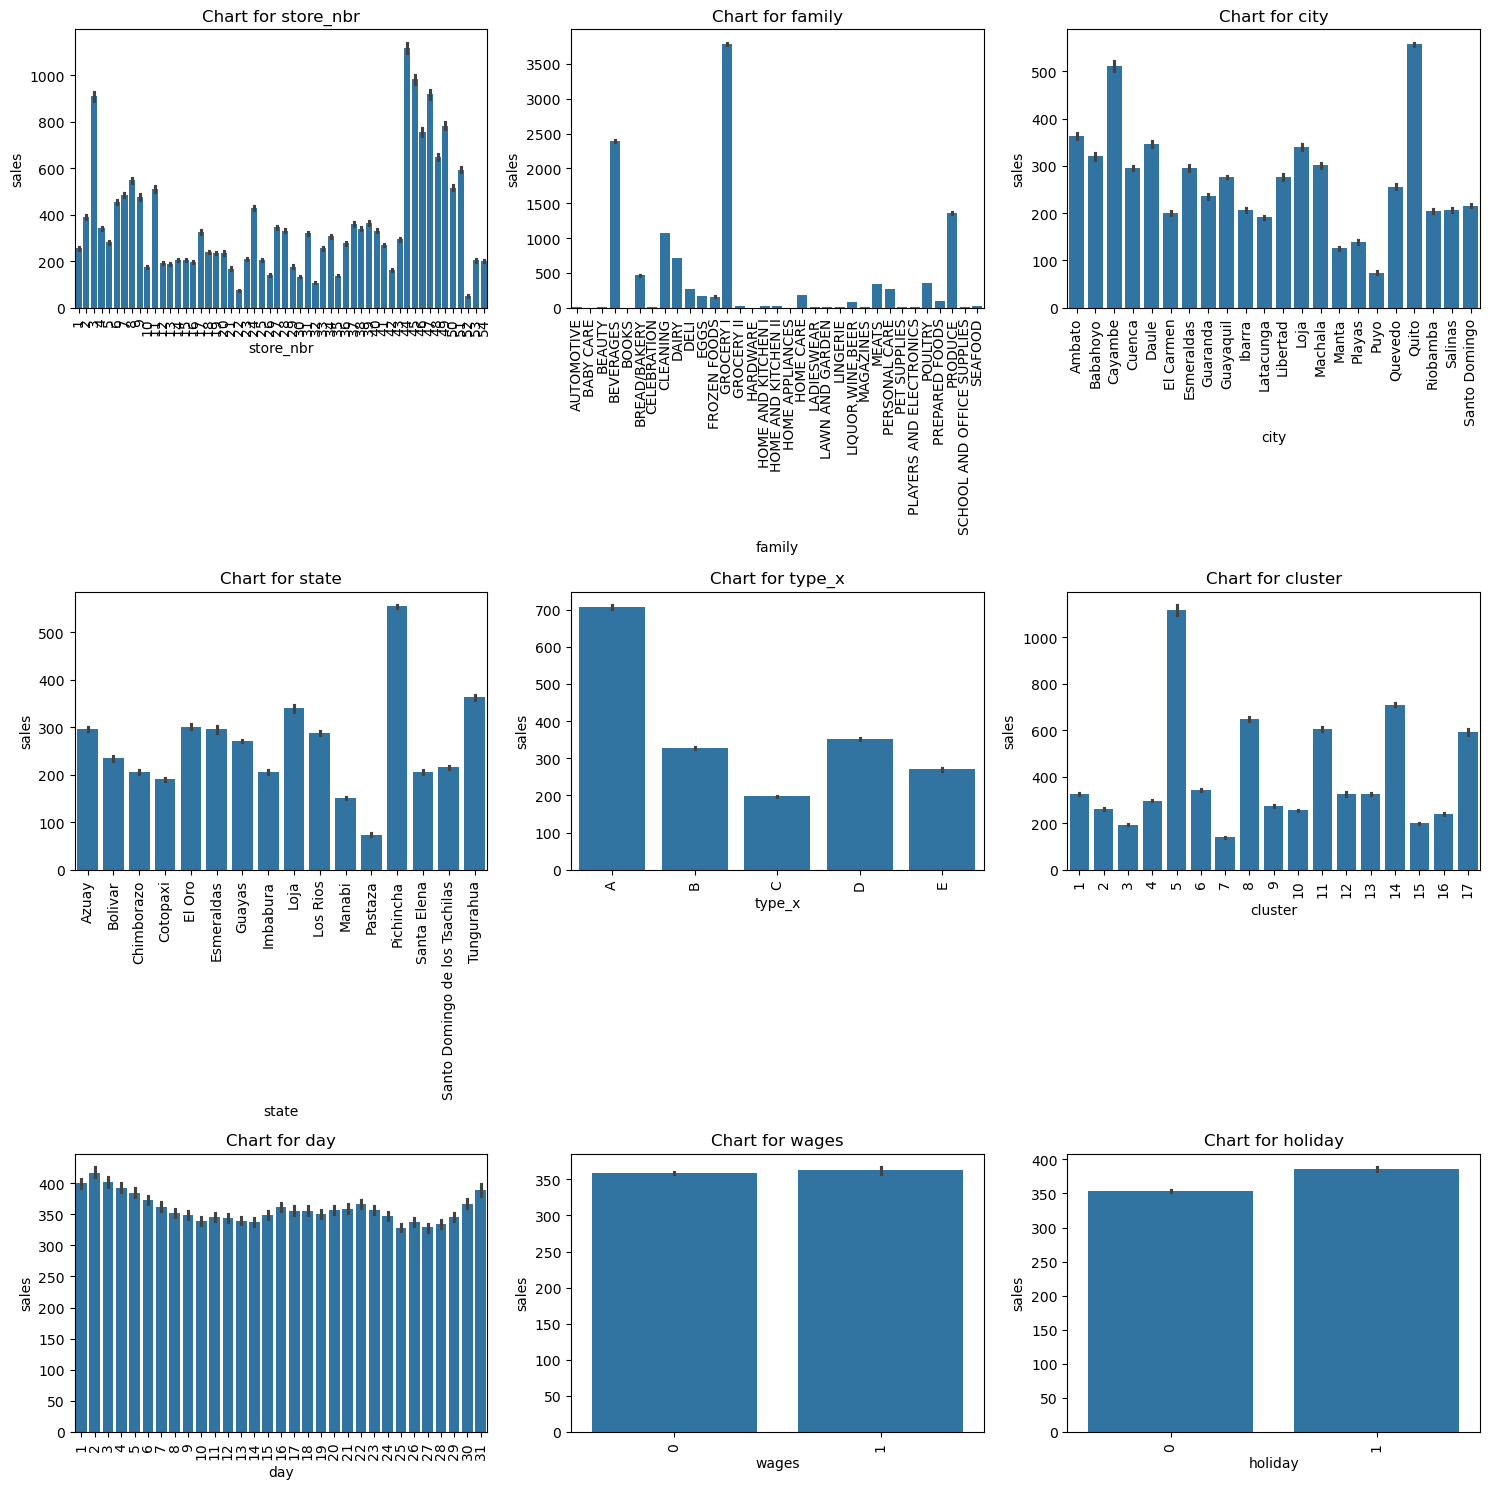

In [57]:
cat_cols = train.select_dtypes(include=['category']).columns

num_rows = len(cat_cols) // 3 + (len(cat_cols) % 3 > 0)
num_cols = min(len(cat_cols), 3)

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 5*num_rows))

for i, col in enumerate(cat_cols):
    ax = axes[i // num_cols, i % num_cols]
    sns.barplot(x=col, y='sales', data= train, ax=ax)
    ax.set_title(f'Chart for {col}')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

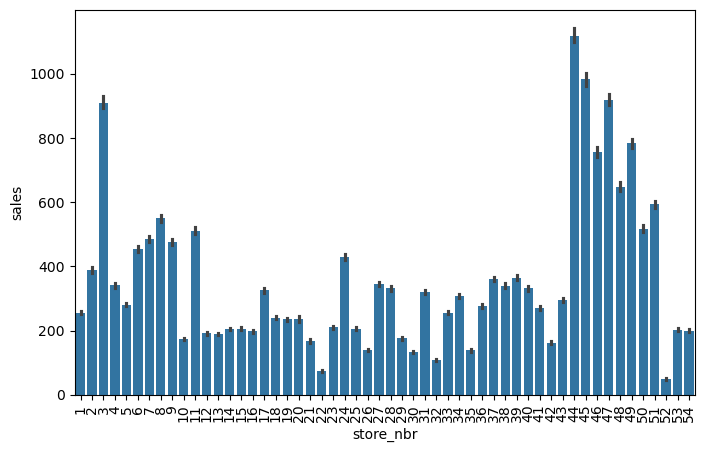

In [58]:
plt.figure(figsize=(8,5))
sns.barplot(data=train, x='store_nbr', y='sales')
plt.xticks(rotation=90)
plt.show()
# store_nbr 44 have highest sales

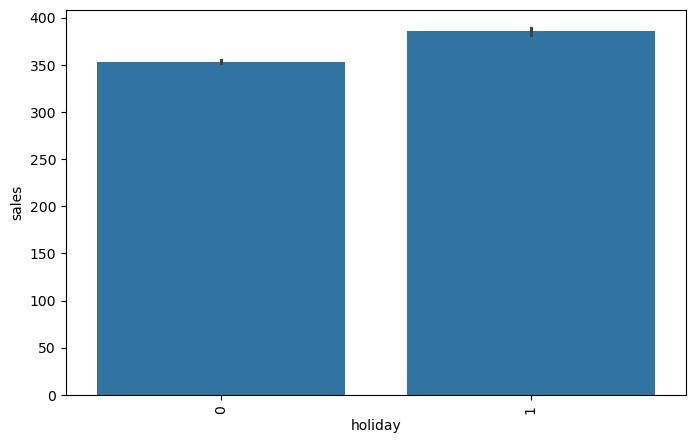

In [59]:
plt.figure(figsize=(8,5))
sns.barplot(data=train, x='holiday', y='sales')
plt.xticks(rotation=90)
plt.show()
# no difference

In [60]:
train['avg_family_sales'] = train.groupby('family')['sales'].transform('mean')

,date,store_nbr,family,sales,onpromotion,ave_transactions,city,state,type_x,cluster,dcoilwtico,day,wages,holiday,avg_family_sales
0,2013-01-01,1,AUTOMOTIVE,0.0,0,0.0,Quito,Pichincha,D,13,93.125,1,0,1,6.115528
1,2013-01-01,1,BABY CARE,0.0,0,0.0,Quito,Pichincha,D,13,93.125,1,0,1,0.111122
2,2013-01-01,1,BEAUTY,0.0,0,0.0,Quito,Pichincha,D,13,93.125,1,0,1,3.727135
3,2013-01-01,1,BEVERAGES,0.0,0,0.0,Quito,Pichincha,D,13,93.125,1,0,1,2391.790527
4,2013-01-01,1,BOOKS,0.0,0,0.0,Quito,Pichincha,D,13,93.125,1,0,1,0.071105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3084637,2017-08-31,9,POULTRY,NaN,1,NaN,Quito,Pichincha,B,6,47.250,31,1,0,350.819336
3084638,2017-08-31,9,PREPARED FOODS,NaN,0,NaN,Quito,Pichincha,B,6,47.250,31,1,0,96.799576
3084639,2017-08-31,9,PRODUCE,NaN,1,NaN,Quito,Pichincha,B,6,47.250,31,1,0,1353.644531
3084640,2017-08-31,9,SCHOOL AND OFFICE SUPPLIES,NaN,9,NaN,Quito,Pichincha,B,6,47.250,31,1,0,2.975672


In [61]:
train.set_index('date', inplace=True)

In [62]:
predictions = []

for family in train['family'].unique():
    for store_nbr in train['store_nbr'].unique():
        family_store_data = train[(train['family'] == family) & (train['store_nbr'] == store_nbr)]['ave_transactions']
        
        model = ARIMA(family_store_data, order=(1, 1, 1))
        model_fit = model.fit()
        
        forecast = model_fit.get_forecast(steps=16)
        forecast_values = forecast.predicted_mean
        
        forecast_df = pd.DataFrame({
            'date': pd.date_range(start='2017-08-16', periods=16, freq='D'),
            'family': family,
            'store_nbr': store_nbr,
            'predicted_transactions': forecast_values
        })
        
        predictions.append(forecast_df)

predictions_df = pd.concat(predictions)
predictions_df

C:\Users\Patson Tan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Patson Tan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Patson Tan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Patson Tan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_pr

,date,family,store_nbr,predicted_transactions
1731,2017-08-16,AUTOMOTIVE,1,44.354938
1732,2017-08-17,AUTOMOTIVE,1,44.354938
1733,2017-08-18,AUTOMOTIVE,1,44.354938
1734,2017-08-19,AUTOMOTIVE,1,44.354938
1735,2017-08-20,AUTOMOTIVE,1,44.354938
...,...,...,...,...
1742,2017-08-27,SEAFOOD,9,61.414046
1743,2017-08-28,SEAFOOD,9,61.414046
1744,2017-08-29,SEAFOOD,9,61.414046
1745,2017-08-30,SEAFOOD,9,61.414046


In [63]:
nums = train.select_dtypes(exclude=['category', 'datetime64[ns]'])

def logs(df, cols):
    df = df.assign(**{f'{col}_log': np.log1p(df[col]) for col in cols})
    df.drop(cols, axis=1, inplace=True)
    return df

skewness = nums.apply(lambda x: skew(x))
skewness = skewness[abs(skewness) > 0.5]
print(str(skewness.shape[0]) + " skewed numerical features to log transform")

train = logs(train, skewness.index)

2 skewed numerical features to log transform


In [64]:
skewness

onpromotion         11.077040
avg_family_sales     3.161675
dtype: float64

In [65]:
train['sales'] = np.log1p(train['sales'])

In [66]:
test= train[train['sales'].isna()] # test data 

In [67]:
test= test.drop(['sales'], axis=1)

In [69]:
merged_df = test.merge(predictions_df[['date', 'store_nbr', 'family', 'predicted_transactions']], 
                       on=['date', 'store_nbr', 'family'], how='left')

In [70]:
test = test.reset_index(drop=True)
merged_df = merged_df.reset_index(drop=True)
test.loc[merged_df['predicted_transactions'].notna(), 'ave_transactions'] = merged_df['predicted_transactions']

In [71]:
train = train.dropna(subset=['sales'])

### Model development

In [74]:
y = train['sales']
X= train.drop(['sales'], axis=1)

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)

In [76]:
xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.1, enable_categorical= True)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print(f'RMSE: {rmse}')

RMSE: 0.3596396744251251


In [77]:
xgb_model.score(X_test,y_test)

0.9821811298706093

In [78]:
cat_cols = X.select_dtypes(include=['category']).columns.tolist()

lgb_model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.1)
lgb_model.fit(X_train, y_train, categorical_feature= cat_cols)
lgb_pred = lgb_model.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.099722 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 934
[LightGBM] [Info] Number of data points in the train set: 2444904, number of used features: 13
[LightGBM] [Info] Start training from score 2.931128


In [79]:
lgb_model.score(X_test,y_test)

0.98268113945658

In [80]:
rmse = np.sqrt(mean_squared_error(y_test, lgb_pred))
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 0.35455786596472616


In [81]:
test_col = test[X.columns]
xgb_predict= np.expm1(xgb_model.predict(test_col))
lgb_predict= np.expm1(lgb_model.predict(test_col))

In [82]:
final_predictions = xgb_predict*0.3 + lgb_predict*0.7

array([ 3.50097501e+00, -6.38420237e-03,  5.37876126e+00, ...,
        1.26933110e+03,  8.31390158e+01,  1.32594023e+01])

In [83]:
result = pd.DataFrame({'Id': passid1, 'sales': np.round(np.maximum(final_predictions, 0),2)})
result.to_csv('submission.csv', index=False) 